# 1.2 Breaking the Notebook

This notebook is designed for a live demo of Jupyter's most important failure mode: **out-of-order execution**.

Run it top-to-bottom once so everything is consistent.

Then do the demo:
1. Go back to **Step 1**.
2. Change `NOISE = 0.25` to `NOISE = 0.50`.
3. Re-run **only** Step 1.
4. Scroll down and show that the later outputs are now stale.

That is the break: the code on screen no longer matches the state that produced the outputs below.

## Setup

Run the next cell once before the rest of the notebook.

In [15]:
# Uncomment if needed:
# %pip install tabicl scikit-learn matplotlib numpy -qq

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tabicl import TabICLClassifier

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## Step 1: Look at the data

Start with clean data. Later, you will come back to this cell, change the noise, and re-run **only this cell**.

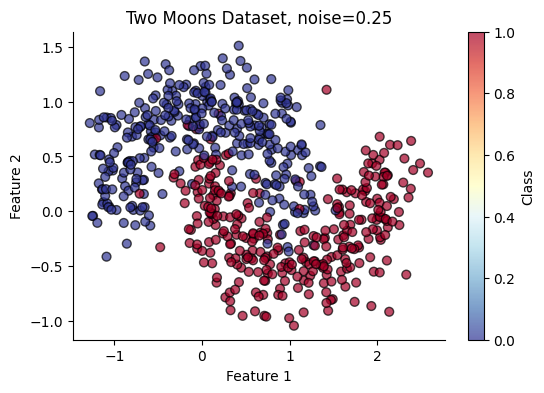

Training samples: 640, Test samples: 160
Current dataset noise in memory: 0.25


In [16]:
NOISE = 0.25
N_SAMPLES = 800

X, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(
    X_train[:, 0], X_train[:, 1], c=y_train,
    cmap="RdYlBu_r", edgecolors="k", s=40, alpha=0.7
)
ax.set(xlabel="Feature 1", ylabel="Feature 2")
ax.set_title(f"Two Moons Dataset, noise={NOISE}")
plt.colorbar(scatter, ax=ax, label="Class")
plt.show()

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Current dataset noise in memory: {NOISE}")

## Step 2: Train TabICL

This cell trains the model on whatever data is currently in memory.

For the demo: after you re-run only Step 1, do **not** re-run this cell.

In [17]:
model = TabICLClassifier()
model.fit(X_train, y_train)
trained_on_noise = NOISE

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba[:, 1])

print(f"Model trained on noise level: {trained_on_noise}")
print(f"Accuracy:  {acc:.3f}")
print(f"ROC AUC:   {roc:.3f}")

Model trained on noise level: 0.25
Accuracy:  0.944
ROC AUC:   0.994


## Step 3: Visualize the decision boundary

This plot is also tied to the model trained in Step 2. If Step 1 changes later, this output becomes stale too.

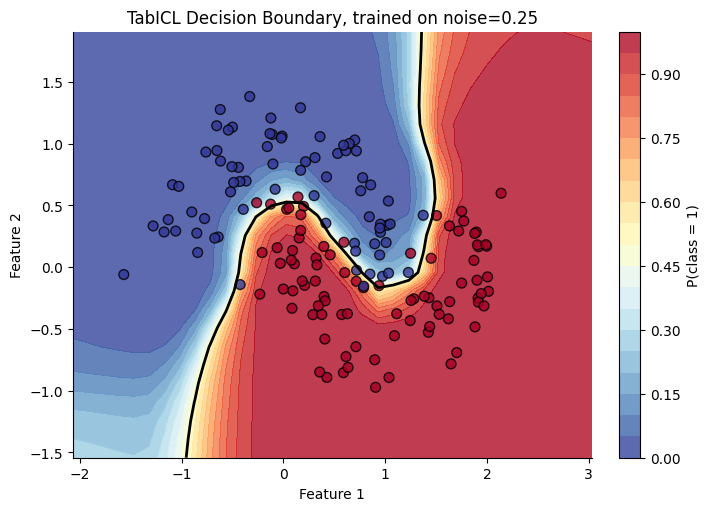

In [18]:
def plot_decision_boundary(model, X_test, y_test, title=None):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    h = 0.15
    offset = 0.5
    x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
    y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.8)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdYlBu_r", edgecolors="k", s=50, alpha=0.8)

    ax.set(xlabel="Feature 1", ylabel="Feature 2")
    if title:
        ax.set_title(title)
    plt.colorbar(contour, ax=ax, label="P(class = 1)")
    plt.show()

plot_decision_boundary(
    model,
    X_test,
    y_test,
    title=f"TabICL Decision Boundary, trained on noise={trained_on_noise}"
)

### Presenter note

After the first clean run, go back to Step 1, change `NOISE` to `0.50`, and re-run only that cell.

Then say:
- The scatter plot changed.
- The accuracy still shows the old result.
- The model was trained on the old data.
- The notebook is now a patchwork of outputs from different states.
- Jupyter gives no warning.

## Step 4: Inspect the mismatch

Do not re-run this during the demo. It is here as another stale output to point at.

In [19]:
print(f"Dataset currently shown in Step 1 used noise={NOISE}")
print(f"But the model below was last trained on noise={trained_on_noise}")

Dataset currently shown in Step 1 used noise=0.25
But the model below was last trained on noise=0.25


## Step 5: Train a second model

This gives you one more result further down the page that also becomes stale if you only re-run Step 1.

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

print(f"Random Forest accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"Random Forest ROC AUC:  {roc_auc_score(y_test, rf_proba[:, 1]):.3f}")

Random Forest accuracy: 0.944
Random Forest ROC AUC:  0.983


## Step 6: Comparison view

This is the section to scroll to and say: "The comparison is also stale. Everything below is from a different state."

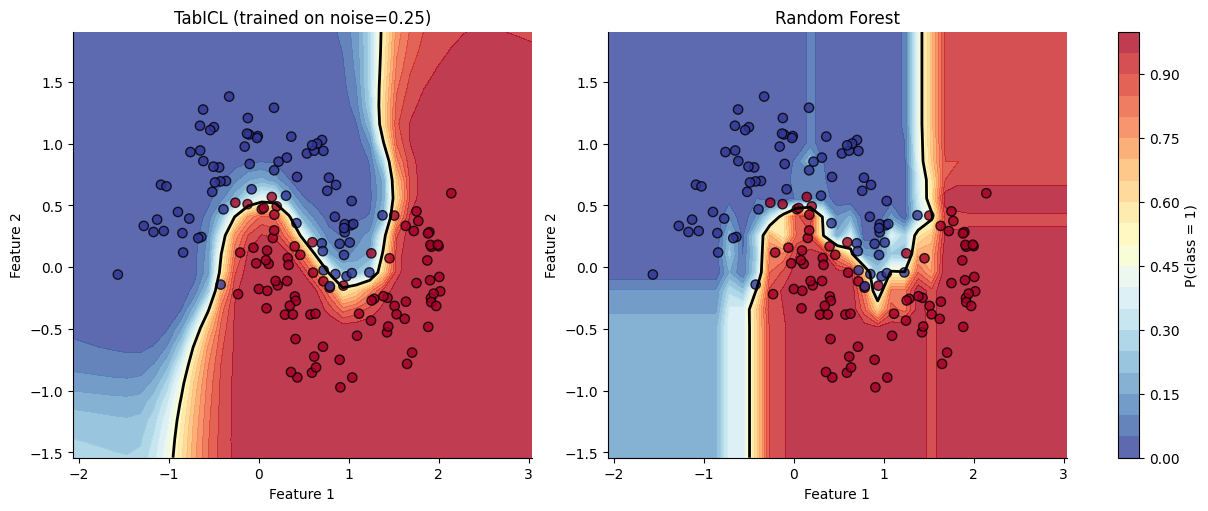

In [21]:
def plot_comparison(models, names, X_test, y_test):
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), constrained_layout=True)
    if len(models) == 1:
        axes = [axes]

    h = 0.15
    offset = 0.5
    x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
    y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    contour = None
    for ax, fitted_model, model_name in zip(axes, models, names):
        Z = fitted_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        Z = Z.reshape(xx.shape)
        contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.8)
        ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdYlBu_r", edgecolors="k", s=45, alpha=0.8)
        ax.set_title(model_name)
        ax.set(xlabel="Feature 1", ylabel="Feature 2")

    plt.colorbar(contour, ax=axes, label="P(class = 1)")
    plt.show()

plot_comparison(
    [model, rf_model],
    [f"TabICL (trained on noise={trained_on_noise})", "Random Forest"],
    X_test,
    y_test,
)

## Step 7: Why people do not just rerun everything

In a tiny demo notebook, rerunning all cells is easy.
In real work, some cells are slow, expensive, or have side effects.

That is why hidden stale state is a real workflow problem, not just a minor inconvenience.

In [ ]:
import time

print("Simulating an expensive downstream cell...")
time.sleep(3)
print("Finished. In a real notebook this could be a long training run, data download, or API call.")
print("That is why people often rerun only part of a notebook, which creates stale state.")

## Step 8: Rerun all may still change the answer

Even if someone says "just rerun everything," that does not guarantee the same result.
Real notebooks often include randomness, timestamps, external data, or API calls.

In [ ]:
demo_score = np.random.uniform(0.82, 0.95)
print(f"Simulated experiment score: {demo_score:.3f}")
print("Run this cell twice: the value changes.")
print("So 'rerun all' is not always a clean rewind to the exact same state.")